# Progetto di Linguistica Computazionale II - Matilde Viti
# Task 2: Classificatore basato su SVM lineari e n-grammi

In [2]:
from sklearn.preprocessing import MaxAbsScaler
from sklearn.feature_extraction import DictVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import numpy as np
import os
import support_task2
import json
from sklearn.pipeline import Pipeline

from support_task2 import load_json


## Definizione classi Document e Token

In [3]:
class Token:
    """ Classe che rappresenta un token con le sue caratteristiche: parola, lemma e parte del discorso (POS). """
    def __init__(self, word, lemma, pos): 
        self.word = word
        self.lemma = lemma
        self.pos = pos
    
    def get_num_chars(self): # Metodo per ottenere il numero di caratteri della parola
        return len(self.word)

class Document:
    def __init__(self, document_path, user_info_dict):
        self.document_path = document_path
        self.doc_id = os.path.splitext(os.path.basename(document_path))[0] # estraiamo il nome del file senza estensione come doc_id
        self.split = user_info_dict[self.doc_id]['split']  # training/test/val
        self.author = user_info_dict[self.doc_id]['author'] # autore del documento
        self.tokens = [] # lista di token che rappresentano le parole del documento
        self.features = None # dizionario che conterrà le caratteristiche del documento, da calcolare successivamente

    def add_token(self, token): # metodo per aggiungere un token alla lista dei token del documento
        self.tokens.append(token)

    def get_words(self): # metodo per ottenere la lista delle parole del documento
        return [t.word for t in self.tokens]

    def get_lemmas(self): # metodo per ottenere la lista dei lemmi del documento 
        return [t.lemma for t in self.tokens]

    def get_pos(self):
        return [t.pos for t in self.tokens]

    def get_num_tokens(self): # metodo per ottenere il numero di token nel documento, che corrisponde al numero di parole
        return len(self.tokens)

    def get_num_lemmas(self):
        return len(self.get_lemmas())

    def get_num_pos(self): # metodo per ottenere il numero di POS unici nel documento
        return len(self.tokens)

    def get_num_chars(self): # metodo per ottenere il numero totale di caratteri nel documento, sommando i caratteri di ogni parola
        return sum(t.get_num_chars() for t in self.tokens) + self.get_num_tokens() - 1
    
    def __str__(self):
        return f"Document ID: {self.doc_id}, Author: {self.author}, Split: {self.split}, Num Tokens: {self.get_num_tokens()}"

In [4]:
def load_document(doc):
    """
    Legge un file .conllu e popola doc.tokens con oggetti Token
    """
    for line in open(doc.document_path, 'r', encoding='utf-8'):
        line = line.strip()
        if line == '' or line.startswith('#'): 
            continue  # salta righe vuote o commenti
        if line[0].isdigit():  # riga con token
            parts = line.split('\t')
            if '-' not in parts[0]:  # evita preposizioni articolate
                token = Token(parts[1], parts[2], parts[3])
                doc.add_token(token)

### Caricamento dei file .conllu estratti da Profiling-UD e del file JSON

In [6]:
conllu_dir = "./file_conllu"
user_info_dict_path = "paragraph_info.json"

# Uso la funzione di supporto per caricare il dizionario
user_info_dict = load_json(user_info_dict_path)

all_documents = []

for file_name in os.listdir(conllu_dir):
    file_path = os.path.join(conllu_dir, file_name)
    if os.path.isfile(file_path):
        doc = Document(file_path, user_info_dict)
        load_document(doc)
        all_documents.append(doc)

print(f"Caricati {len(all_documents)} documenti")

Caricati 5506 documenti


## Prima configurazione




In [7]:
# Prima configurazione
first_config = [("pos", 2), ("lemma", 3), ("word", 2), ("char", 3)]

# # estraiamo e normalizziamo gli n-gram
support_task2.extract_all_ngrams(all_documents, first_config)

In [8]:
# divisione in train, val, test
first_X_train, first_y_train, first_X_val, first_y_val, first_X_test, first_y_test = support_task2.split_dataset(all_documents)

print("Train:", len(first_X_train), len(first_y_train))
print("Validation:", len(first_X_val), len(first_y_val))
print("Test:", len(first_X_test), len(first_y_test))



Train: 4312 4312
Validation: 600 600
Test: 594 594


In [9]:
def get_num_features(features_list):
    all_features = set()
    for features in features_list:      # itera su ogni dizionario/documento
        all_features.update(features.keys())
    return len(all_features)

print(f"Numero di features: {get_num_features(first_X_train)}")

Numero di features: 398239


# Filtro feature

In [10]:
def filter_features(train_features_dict, min_occurrences):
    # conta in quanti documenti compare ogni feature
    features_counter = {}

    for document_features_dict in train_features_dict:
        for feature in document_features_dict:
            features_counter[feature] = features_counter.get(feature, 0) + 1

    # rimuove le feature troppo rare
    for document_features_dict in train_features_dict:
        for feature in list(document_features_dict.keys()):
            if features_counter[feature] < min_occurrences:
                document_features_dict.pop(feature)

    return train_features_dict

first_feat_X_train = filter_features(first_X_train, 5) # rimuove le feature che compaiono in meno di 5 documenti nel training set

print(f"Numero di features dopo il filtraggio: {get_num_features(first_feat_X_train)}")

Numero di features dopo il filtraggio: 22111


# Addestramento modello e valutazione delle configurazioni sul validation set (prima configurazione)

In [11]:
# trasformazione da dizionario a matrice
vectorizer = DictVectorizer()
X_train_matrix_first = vectorizer.fit_transform(first_feat_X_train)
X_val_matrix_first = vectorizer.transform(first_X_val)          # usa lo stesso vectorizer
X_test_matrix_first = vectorizer.transform(first_X_test)        # idem per il test set

# 2. Pipeline con scaler che supporta matrici sparse
pipeline_first = Pipeline([
    ("scaler", MaxAbsScaler()),  # divide ogni feature per il suo massimo valore assoluto
    ("svc", LinearSVC(
        C=1.0,
        class_weight="balanced",  
        dual=False,
        max_iter=10000,
        random_state=42
    ))
])


# 3. Addestramento del modello
pipeline_first.fit(X_train_matrix_first, first_y_train)

# 4. Valutazione
first_y_pred = pipeline_first.predict(X_val_matrix_first)

print(classification_report(first_y_val, first_y_pred))

                  precision    recall  f1-score   support

Charlotte Bronte       0.85      0.83      0.84       200
    George Eliot       0.81      0.94      0.87       200
     Jane Austen       0.94      0.81      0.87       200

        accuracy                           0.86       600
       macro avg       0.87      0.86      0.86       600
    weighted avg       0.87      0.86      0.86       600



# Seconda configurazione

In [12]:
# Seconda configurazione

sec_config = [("pos", 3), ("lemma", 2), ("word", 3), ("char", 2)]

# estraiamo e normalizziamo gli n-gram
support_task2.extract_all_ngrams(all_documents, sec_config)

In [13]:
# divisione in train, val, test
second_X_train, second_y_train, second_X_val, second_y_val, second_X_test, second_y_test = support_task2.split_dataset(all_documents)

print("Train:", len(second_X_train), len(second_y_train))
print("Validation:", len(second_X_val), len(second_y_val))
print("Test:", len(second_X_test), len(second_y_test))



Train: 4312 4312
Validation: 600 600
Test: 594 594


In [14]:
def get_num_features(features_dict):
    all_features = set()
    for document_feats in features_dict:
        all_features.update(list(document_feats.keys()))
    return len(all_features)

get_num_features(second_X_train)
print(f'Number of features: {get_num_features(second_X_train)}')

Number of features: 390869


In [15]:
def filter_features(train_features_dict, min_occurrences):
    # conta in quanti documenti compare ogni feature
    features_counter = {}

    for document_features_dict in train_features_dict:
        for feature in document_features_dict:
            features_counter[feature] = features_counter.get(feature, 0) + 1

    # rimuove le feature troppo rare
    for document_features_dict in train_features_dict:
        for feature in list(document_features_dict.keys()):
            if features_counter[feature] < min_occurrences:
                document_features_dict.pop(feature)

    return train_features_dict

second_feat_X_train = filter_features(second_X_train, 5) # rimuove le feature che compaiono in meno di 5 documenti nel training set
print("Numero di feature dopo il filtro:", len(second_feat_X_train[0]))


Numero di feature dopo il filtro: 272


In [16]:
# trasformazione da dizionario a matrice
vectorizer = DictVectorizer()
X_train_matrix_second = vectorizer.fit_transform(second_feat_X_train)
X_val_matrix_second = vectorizer.transform(second_X_val)          # usa lo stesso vectorizer
X_test_matrix_second = vectorizer.transform(second_X_test)        # idem per il test set

# 2. Pipeline con scaler che supporta matrici sparse
pipeline_second = Pipeline([
    ("scaler", MaxAbsScaler()),  # divide ogni feature per il suo massimo valore assoluto
    ("svc", LinearSVC(
        C=1.0,
        class_weight="balanced",  
        dual=False,
        max_iter=10000,
        random_state=42
    ))
])


# 3. Addestramento del modello
pipeline_second.fit(X_train_matrix_second, second_y_train)

# 4. Valutazione
second_y_pred = pipeline_second.predict(X_val_matrix_second)

print(classification_report(second_y_val, second_y_pred))

                  precision    recall  f1-score   support

Charlotte Bronte       0.83      0.88      0.85       200
    George Eliot       0.83      0.94      0.88       200
     Jane Austen       0.96      0.79      0.87       200

        accuracy                           0.86       600
       macro avg       0.87      0.87      0.86       600
    weighted avg       0.87      0.86      0.86       600



## Terza configurazione

In [17]:
# # Terza configurazione
third_config =  [("pos", 2), ("lemma", 2), ("word", 1), ("char", 3)]
# # estraiamo e normalizziamo gli n-gram
support_task2.extract_all_ngrams(all_documents, third_config)

In [18]:
# divisione in train, val, test
third_X_train, third_y_train, third_X_val, third_y_val, third_X_test, third_y_test = support_task2.split_dataset(all_documents)

print("Train:", len(third_X_train), len(third_y_train))
print("Validation:", len(third_X_val), len(third_y_val))
print("Test:", len(third_X_test), len(third_y_test))


Train: 4312 4312
Validation: 600 600
Test: 594 594


In [19]:
def get_num_features(features_list):
    all_features = set()
    for features in features_list:      # itera su ogni dizionario/documento
        all_features.update(features.keys())
    return len(all_features)

print(f"Numero di features: {get_num_features(third_X_train)}")

Numero di features: 139558


In [20]:
def filter_features(train_features_dict, min_occurrences):
    # conta in quanti documenti compare ogni feature
    features_counter = {}

    for document_features_dict in train_features_dict:
        for feature in document_features_dict:
            features_counter[feature] = features_counter.get(feature, 0) + 1

    # rimuove le feature troppo rare
    for document_features_dict in train_features_dict:
        for feature in list(document_features_dict.keys()):
            if features_counter[feature] < min_occurrences:
                document_features_dict.pop(feature)

    return train_features_dict

third_feat_X_train = filter_features(third_X_train, 5) # rimuove le feature che compaiono in meno di 5 documenti nel training set

print(f"Numero di features dopo il filtraggio: {get_num_features(third_feat_X_train)}")

Numero di features dopo il filtraggio: 20528


In [21]:
# trasformazione da dizionario a matrice
vectorizer = DictVectorizer()
X_train_matrix_third = vectorizer.fit_transform(third_feat_X_train)
X_val_matrix_third = vectorizer.transform(third_X_val)          # usa lo stesso vectorizer
X_test_matrix_third= vectorizer.transform(third_X_test)        # idem per il test set

# 2. Pipeline con scaler che supporta matrici sparse
pipeline_third = Pipeline([
    ("scaler", MaxAbsScaler()),  # divide ogni feature per il suo massimo valore assoluto
    ("svc", LinearSVC(
        C=1.0,
        class_weight="balanced",  
        dual=False,
        max_iter=10000,
        random_state=42
    ))
])


# 3. Addestramento del modello
pipeline_third.fit(X_train_matrix_third, third_y_train)

# 4. Valutazione
third_y_pred = pipeline_third.predict(X_val_matrix_third)

print(classification_report(third_y_val, third_y_pred))

                  precision    recall  f1-score   support

Charlotte Bronte       0.86      0.82      0.84       200
    George Eliot       0.83      0.94      0.88       200
     Jane Austen       0.92      0.83      0.87       200

        accuracy                           0.86       600
       macro avg       0.87      0.86      0.86       600
    weighted avg       0.87      0.86      0.86       600



# Applicazione sul test set (seconda configurazione)


In [22]:
# --- Predizione sul test set ---
second_y_test_pred = pipeline_second.predict(X_test_matrix_second)
print("\n--- Test Results ---")
print(classification_report(second_y_test, second_y_test_pred))


--- Test Results ---
                  precision    recall  f1-score   support

Charlotte Bronte       0.82      0.85      0.83       194
    George Eliot       0.78      0.91      0.84       200
     Jane Austen       0.92      0.73      0.82       200

        accuracy                           0.83       594
       macro avg       0.84      0.83      0.83       594
    weighted avg       0.84      0.83      0.83       594



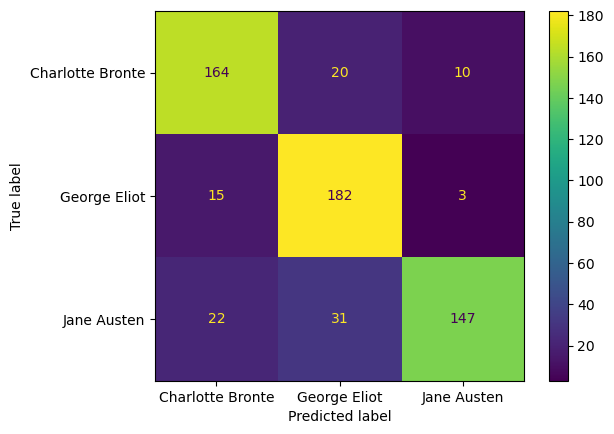

In [23]:
# Confusion matrix del test set
ConfusionMatrixDisplay.from_predictions(second_y_test, second_y_test_pred, display_labels=pipeline_second.classes_)
